# Kunming AI+ &mdash; Practical Workshop 4

In this notebook, we'll work through one dataset end to end:

1. Correlation study — how do the features relate?
2. PCA — how to compress correlated features into a few principal components.
3. A PyTorch MLP — a custom MLP for binary classification.
4. Feature importance — which inputs does the model actually rely on?
5. k-fold cross-validation — an honest estimate of generalisation performance.
6. The confusion matrix — look past accuracy at which errors we make.

We'll work with the breast-cancer dataset from a few lectures ago. The dataset consists of 569 tumours, 30 numeric features computed from a biopsy image, each labelled benign or malignant. We treat it as a screening problem, so the positive class we must not miss is malignant.

## Part 0 — Setup

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier

SEED = 0
np.random.seed(SEED)
torch.manual_seed(SEED)

In [2]:
data = load_breast_cancer(as_frame=True)
X = data.data                              # 30 named features
y = (data.target == 0).astype(int)         # relabel: 1 = malignant (disease), 0 = benign

print("samples, features:", X.shape)
print("class balance -> benign:", int((y == 0).sum()), "| malignant:", int((y == 1).sum()))
X.iloc[:, :6].head()

print("All feature names:", list(X.columns))

samples, features: (569, 30)
class balance -> benign: 357 | malignant: 212
All feature names: ['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness', 'mean compactness', 'mean concavity', 'mean concave points', 'mean symmetry', 'mean fractal dimension', 'radius error', 'texture error', 'perimeter error', 'area error', 'smoothness error', 'compactness error', 'concavity error', 'concave points error', 'symmetry error', 'fractal dimension error', 'worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


Let's create a training and testing dataset, ensuring we stratify to keep the same class imbalance.

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

print("number of training samples:", X_train.shape[0], "| number of test samples:", X_test.shape[0])

number of training samples: 426 | number of test samples: 143


## Part 1 — Correlation study

A correlation matrix shows which features comove. Since the dataset reports statistics of features such as the mean, standard error and worst value of each measurement, many features will definitely be correlated, and as such, removeable.

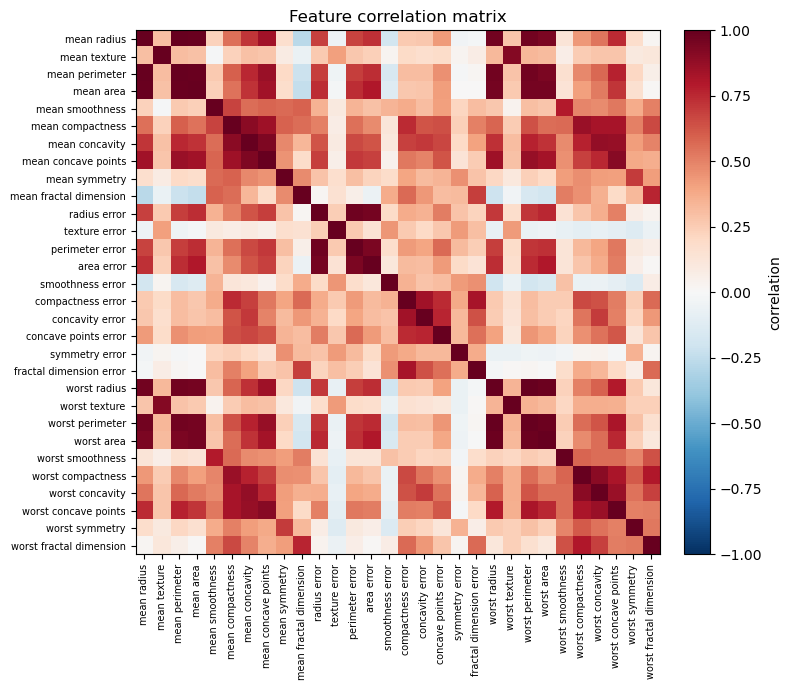

In [5]:
corr = X_train.corr()

fig, ax = plt.subplots(figsize=(8, 7))

im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)

ax.set_xticks(range(len(corr))); ax.set_yticks(range(len(corr)))
ax.set_xticklabels(corr.columns, rotation=90, fontsize=7)
ax.set_yticklabels(corr.columns, fontsize=7)

fig.colorbar(im, fraction=0.046, pad=0.04, label="correlation")

ax.set_title("Feature correlation matrix")

plt.tight_layout()
plt.show()

Let's extract the most strongly correlated pairs directly to identify which features are carrying almost the same amount of information.

In [6]:
mask = np.triu(np.ones(corr.shape), k=1).astype(bool)   # upper triangle matrix, no diagonal

top_pairs = corr.abs().where(mask).stack().sort_values(ascending=False)

top_pairs.head(8)

mean radius      mean perimeter     0.997828
worst radius     worst perimeter    0.993669
mean radius      mean area          0.986125
mean perimeter   mean area          0.985449
worst radius     worst area         0.983400
worst perimeter  worst area         0.977789
radius error     perimeter error    0.974398
mean perimeter   worst radius       0.967533
dtype: float64

`mean radius`, `mean perimeter` and `mean area` are 0.99 correlated! This is to be expected since perimeter and area are functions of the radius. Keeping all three adds little information, which motivates the next two steps.

## Part 2 — PCA

PCA re-expresses the data along orthogonal directions ordered by variance. It is scale-sensitive, so we standardise first, fitting the scaler on the training set only, as to not introduce any data leakage.

10 of 30 components explain >= 95% of the variance


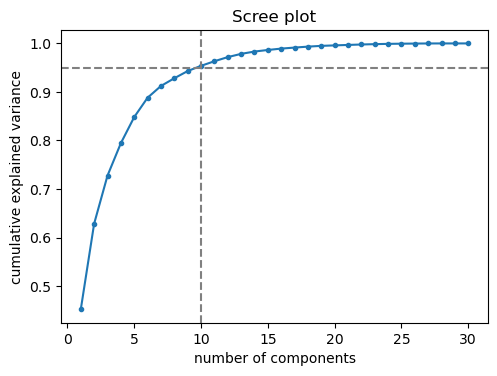

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

scaler = StandardScaler().fit(X_train)
X_train_std = scaler.transform(X_train)

pca_full = PCA().fit(X_train_std)
cumulative = np.cumsum(pca_full.explained_variance_ratio_)

k95 = int(np.argmax(cumulative >= 0.95) + 1)
print(f"{k95} of {X.shape[1]} components explain >= 95% of the variance")

fig, ax = plt.subplots(figsize=(5.5, 3.8))
ax.plot(range(1, len(cumulative) + 1), cumulative, marker=".")
ax.axhline(0.95, color="grey", ls="--"); ax.axvline(k95, color="grey", ls="--")
ax.set_xlabel("number of components"); ax.set_ylabel("cumulative explained variance")
ax.set_title("Scree plot")
plt.show()

With 10 components, we're able to capture 95% of the variation found in 30 features! Interestingly, below, just projecting the data onto the first two features separates the classes well.

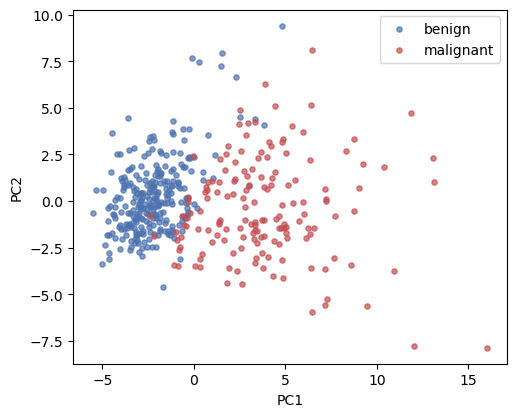

In [8]:
pca_2 = PCA(n_components=2).fit(X_train_std)
Z     = pca_2.transform(X_train_std)

fig, ax = plt.subplots(figsize=(5.6, 4.6))

for cls, name, colour in [(0, "benign", "#4C72B0"), (1, "malignant", "#C44E52")]:
    ax.scatter(Z[y_train == cls, 0], Z[y_train == cls, 1], s=14, alpha=0.7, label=name, color=colour)
    
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.show()

The following shows how to ask PCA to automatically select the number of components such that we capture 95% of the variation, and then, transform the data accordingly.

In [9]:
pca = PCA(n_components=0.95).fit(X_train_std)

print("Number of components kept:", pca.n_components_)
print("Original data shape:", X_train.shape, " | New shape:", pca.transform(X_train_std).shape)

Number of components kept: 10
Original data shape: (426, 30)  | New shape: (426, 10)


## Part 3 — MLP 

For getting to grips with the remainder of the content from the slides, we'll need an MLP. We'll keep it simple with two hidden layers with ReLU
and dropout, ending in a single output. 

The loss function we'll use for training is `BCEWithLogitsLoss`, a standard loss function used in binary classification.

That output of the MLP is a raw **logit**, which when passed through a sigmoid, return the probablity of whether the input is malignant or benign. 

Within `BCEWithLogitsLoss`, there already exists a sigmoid to do this transformation, hence, nothing special needs to be done at training. At evaluation, you must do this yourself.

PCA-style methods are scale-sensitive and so are neural nets, so we train on the **standardised** features (`X_train_std`, from the scaler we already fit on the training data above).

In [10]:
class MLP(nn.Module):
    """Small MLP for binary classification. Outputs one raw logit per sample."""
    def __init__(self, in_dim, hidden=32, p_drop=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, hidden), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(hidden, 1))

    def forward(self, x):
        return self.net(x).squeeze(1)


def make_loader(Xz, yz, batch_size=32, shuffle=True):
    ds = TensorDataset(torch.tensor(Xz, dtype=torch.float32), torch.tensor(np.asarray(yz), dtype=torch.float32))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_mlp(Xz, yz, in_dim, epochs=60, lr=1e-3, seed=SEED):
    """Train a fresh MLP on already-scaled inputs and return it."""
    torch.manual_seed(seed)

    model = MLP(in_dim)
    optimiser   = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.BCEWithLogitsLoss()

    train_loader = make_loader(Xz, yz)

    model.train()
    for _ in range(epochs):
        for xb, yb in train_loader:
            optimiser.zero_grad()
            raw_logits = model(xb)
            loss = loss_fn(raw_logits, yb)
            loss.backward()
            optimiser.step()
    return model


@torch.no_grad()
def mlp_proba(model, Xz):
    """Return the probability of the input being malignant by passing the raw logits through a sigmoid."""
    model.eval()
    raw_logits = model(torch.tensor(Xz, dtype=torch.float32))
    return torch.sigmoid(raw_logits).numpy()


def mlp_accuracy(model, Xz, yz):
    """
    Return the accuracy of the model. We treat a probablity of greater than 0.5 as a malignant prediction.
    Hence, we count the mean number of predictions that correctly identify a sample as malignant.
    """
    return ((mlp_proba(model, Xz) >= 0.5).astype(int) == np.asarray(yz)).mean()


# train our model on all the (standardised) training data
mlp = train_mlp(X_train_std, y_train.to_numpy(), in_dim=X_train_std.shape[1])
print("fits the training data — accuracy:", round(mlp_accuracy(mlp, X_train_std, y_train.to_numpy()), 3))

fits the training data — accuracy: 0.995


## Part 4 — Feature importance

Now we've trained our MLP, we can analyse which inputs the model really depends on. To conduct feature importance we will take one feature, shuffle its column, and measure how far test accuracy falls. A big drop means the model leaned on that feature, while a small drop means it didn't. We repeat the shuffle several times per feature and average, since the shuffle is random.

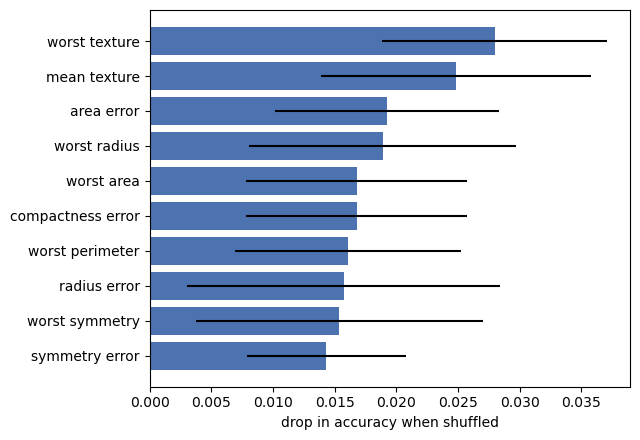

In [ ]:
X_test_std = scaler.transform(X_test)               # Use the scaler computed on the training set to scale the test set
base_acc   = mlp_accuracy(mlp, X_test_std, y_test.to_numpy())

rng = np.random.default_rng(SEED)
n_repeats = 20 
drops = np.zeros((X.shape[1], n_repeats))
y_te  = y_test.to_numpy()

# Loop through each feature and shuffle it n_repeats times to average out the randomness of the shuffle
for feature in range(X.shape[1]):
    for r in range(n_repeats):
        X_shuffled = X_test_std.copy()
        rng.shuffle(X_shuffled[:, feature])
        drops[feature, r] = base_acc - mlp_accuracy(mlp, X_shuffled, y_te)

imp = pd.DataFrame({"mean": drops.mean(1), "std": drops.std(1)}, index=X.columns).sort_values("mean")
top = imp.tail(10)

fig, ax = plt.subplots(figsize=(6.5, 4.5))

ax.barh(top.index, top["mean"], xerr=top["std"], color="#4C72B0")
ax.set_xlabel("drop in accuracy when shuffled")
plt.tight_layout()
plt.show()

Notice the drops are modest and fairly even. This is showcasing the  redundancy we saw in step 1 showing up again. Since many features are near-duplicates (mean / standard-error / worst versions of the same measurement), the model can fall back on a correlated substitute when one is shuffled, so no single feature is
irreplaceable.

## Part 5 — k-fold cross-validation

A single train/test split is noisy. k-fold cross-validation splits the training data into k parts, trains on k-1 and validates on the held-out part, k times, then averages. `StratifiedKFold` keeps the class balance in each fold.

scikit-learn can run this loop for its own models, but since our model is a PyTorch network, we will write the loop ourselves. The loop below is exactly the k-fold algorithm from the slides. For each fold we fit the scaler on that fold's training part only (to avoid data leakage), train a fresh MLP, and score the held-out part.

In [12]:
from sklearn.model_selection import StratifiedKFold

def cross_validate_mlp(X_df, y_sr, use_pca=False, var=0.95, epochs=60):

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

    scores, n_comp = [], None

    for tr_idx, va_idx in cv.split(X_df, y_sr):
        
        X_tr_raw = X_df.iloc[tr_idx]
        X_va_raw = X_df.iloc[va_idx]
        y_tr     = y_sr.iloc[tr_idx].to_numpy()
        y_va     = y_sr.iloc[va_idx].to_numpy()

        # preprocessing fit INSIDE the fold (train part only) -> no leakage
        fold_scaler = StandardScaler().fit(X_tr_raw)
        X_tr       = fold_scaler.transform(X_tr_raw)
        X_va       = fold_scaler.transform(X_va_raw)

        if use_pca:
            pca = PCA(n_components=var, random_state=SEED).fit(X_tr)
            X_tr = pca.transform(X_tr)
            X_va = pca.transform(X_va)
            n_comp = pca.n_components_

        model = train_mlp(X_tr, y_tr, in_dim=X_tr.shape[1], epochs=epochs)
        scores.append(mlp_accuracy(model, X_va, y_va))

    return np.array(scores), n_comp


baseline = DummyClassifier(strategy="most_frequent").fit(X_train, y_train)
scores, _ = cross_validate_mlp(X_train, y_train)

print(f"{'Baseline (always benign)':26s} {baseline.score(X_train, y_train):.3f}")
print(f"{'MLP (30 features)':26s} {scores.mean():.3f}  +/-  {scores.std():.3f}")
print("per-fold:", np.round(scores, 3))

Baseline (always benign)   0.627
MLP (30 features)          0.981  +/-  0.006
per-fold: [0.988 0.976 0.988 0.976 0.976]


### Using PCA as a preprocessing step for training

Earlier, we saw PCA as a way to analyse data. It is also a preprocessing step you can train on: project the standardised inputs onto their top principal components, then feed those components to the model instead of the 30 raw features. Precaution is still required to ensure data leakage is avoided, and so, fit PCA inside each fold. In the loop above that is the single flag `use_pca=True`, which adds two lines: `PCA(...).fit(X_tr)` then `transform` both parts.

In [13]:
scores_pca, k = cross_validate_mlp(X_train, y_train, use_pca=True, var=0.95)

print(f"{'MLP (30 features)':26s} {scores.mean():.3f}  +/-  {scores.std():.3f}")
print(f"{f'MLP ({k} PCA components)':26s} {scores_pca.mean():.3f}  +/-  {scores_pca.std():.3f}")

MLP (30 features)          0.981  +/-  0.006
MLP (10 PCA components)    0.976  +/-  0.018


The MLP comfortably beats the baseline, and the PCA version matches even with a third of the inputs.

## Part 6 — The confusion matrix

Cross-validation showed the architecture generalises well. Now we evaluate the model we trained on all the training data on the held-out test set. We saw how accuracy can be a metric which hides the true performance of the model, so we look at the confusion matrix and the per-class precision and recall.

test accuracy: 0.972 

              precision    recall  f1-score   support

      benign       0.99      0.97      0.98        90
   malignant       0.95      0.98      0.96        53

    accuracy                           0.97       143
   macro avg       0.97      0.97      0.97       143
weighted avg       0.97      0.97      0.97       143



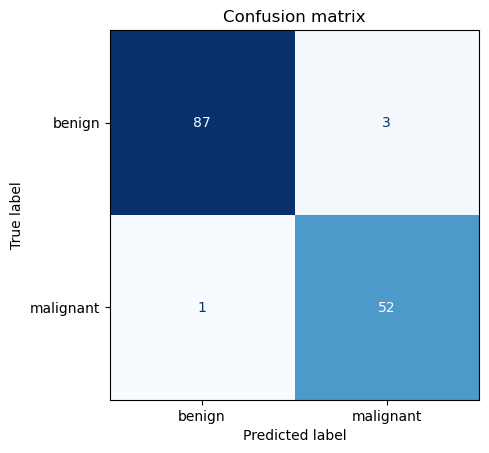

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, precision_score, recall_score

proba  = mlp_proba(mlp, X_test_std)
y_pred = (proba >= 0.5).astype(int)

print("test accuracy:", round((y_pred == y_test.to_numpy()).mean(), 3),"\n")
print(classification_report(y_test, y_pred, target_names=["benign", "malignant"]))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=["benign", "malignant"], cmap="Blues", colorbar=False)
plt.title("Confusion matrix")
plt.show()

The dangerous error in screening is a alse negative, where a malignant tumour is predicted benign. That is what recall for the malignant class measures.

If missing a malignancy is far worse than a false alarm, we can lower the decision threshold to flag more cases, trading precision for recall.

In [15]:
for thresh in (0.5, 0.3, 0.2):
    pred = (proba >= thresh).astype(int)
    print(f"threshold {thresh:.1f}  | precision {precision_score(y_test, pred):.3f} recall {recall_score(y_test, pred):.3f}")

threshold 0.5  | precision 0.945 recall 0.981
threshold 0.3  | precision 0.929 recall 0.981
threshold 0.2  | precision 0.881 recall 0.981


Lowering the threshold raises recall (fewer missed malignancies) at the cost of more false alarms. The right balance depends on the real-world cost of each error.

### Next: Academic Lecture 1

For our first of two academic lectures, I'll be going into the use case of machine learning in the field of science. True scientific machine learning is not just appliying an MLP to scientific data. It really is a science to develop model architectures that can perform well on specific scientific systems.